In [1]:
import torch
import torch.nn as nn

import torch_geometric as tg
import torch_geometric.utils as tgu
import torch_geometric.nn as tgnn
import matplotlib.pyplot as plt

import numpy as np

In [2]:
omega = 1.8

feature_vec_len = 8
x = np.arange(0,5,0.1).reshape((-1,1))
y = np.arange(0,5,0.1).reshape((-1,1))
t = np.arange(0,6,0.1).reshape([-1,1,1])

xy = np.sqrt(x**2 + y.T**2).reshape([1,x.shape[0],y.shape[0]])

values = np.sin(omega*t + xy)

edge_embedding_size = 4 
edge_params = torch.rand([*xy.shape,4])
bias = torch.rand([*xy.shape, feature_vec_len])

In [164]:
base_samples = [(10,10), (40,10), (10,40), (40,40), (25,25)]
# values refers to measured value -> shape [time, *xy.shape]
# xy refers to class of measurment
# t refers to time of measurment
def get_sample(values, xy):
    number_of_additional_nodes = np.random.randint(8,12)
    number_of_nodes_to_predict = np.random.randint(16,32)
    rand_coordinates = set(base_samples + [tuple(np.random.randint(0,values.shape[1], [2,])) for _ in range(number_of_additional_nodes)])
    cord_to_predict = []
    it = 0
    while number_of_nodes_to_predict > len(cord_to_predict):
        it += 1
        candidate = tuple(np.random.randint(0,values.shape[1], [2,]))
        if candidate not in rand_coordinates:
            cord_to_predict.append(candidate)
        if it>120:
            raise Exception("something is wrong in while loop")

    time = np.random.randint(0,50)
    dt = 4#np.random.randint(4, min(60-time-1,12))

    inp_known = []
    inp_unknown = []
    out_t_0 = []
    out_t_dt = []
    list_of_node_classes = []

    for cord in rand_coordinates:
        inp_known.append((*cord, time, values[time,*cord]))
        out_t_0.append((*cord, time, values[time,*cord]))
        out_t_dt.append((*cord, time+dt, values[time+dt,*cord]))
        list_of_node_classes.append(cord)

    for cord in cord_to_predict:
        inp_unknown.append(cord)
        out_t_0.append((*cord, time, values[time,*cord]))
        out_t_dt.append((*cord, time+dt, values[time+dt,*cord]))
        list_of_node_classes.append(cord)

    fully_connected_adj = torch.ones(len(out_t_0), len(out_t_0))
    fully_connected = tgu.dense_to_sparse(fully_connected_adj)[0]

    partially_connected_adj = torch.ones(len(out_t_0), len(out_t_0))
    #partially_connected_adj[len(rand_coordinates):, :len(rand_coordinates)] = 0
    partially_connected_adj[:, :len(rand_coordinates)] = 0
    partially_connected = tgu.dense_to_sparse(partially_connected_adj)[0]

    return (
        (fully_connected, list_of_node_classes, partially_connected),
        (torch.tensor(inp_known, dtype=torch.float32), torch.tensor(inp_unknown, dtype=torch.int32)),
        torch.tensor(out_t_0, dtype=torch.float32),
        torch.tensor(out_t_dt, dtype=torch.float32),
        torch.tensor([[time], [time+dt]]).to(torch.float32),
    )

In [165]:
class feature_encoder(nn.Module):
    def __init__(self, dims=None, output_feature_num=feature_vec_len):
        nn.Module.__init__(self)

        if dims is None:
            self.dims = {
                "time": 1,
                "x_pos": 1,
                "y_pos": 1,
                "value": 1,
            } 
        else:
            self.dims = dims

        self.input_dimensionality = sum(self.dims.values())

        self.seq = nn.Sequential(
            nn.Linear(self.input_dimensionality, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU(),
            nn.Linear(32, output_feature_num),
            nn.Tanh()
        )

    def forward(self, x):
        return self.seq(x)

In [166]:
fe_model = feature_encoder()
te = feature_encoder({'time': 1}, output_feature_num=16)
sample = get_sample(values, xy)
fe_model(sample[1][0])

tensor([[ 0.9884,  0.8279, -0.6435, -0.9723, -0.1757,  0.9564,  0.9684, -0.5248],
        [ 0.9548,  0.8155, -0.6238, -0.9482, -0.2409,  0.9545,  0.9302, -0.4999],
        [ 0.8418,  0.7633,  0.2914, -0.8831,  0.3978,  0.8989,  0.7108,  0.1171],
        [ 0.8346,  0.9513,  0.9582, -0.7976,  0.9677,  0.5779,  0.2734,  0.8012],
        [ 0.7110,  0.9110,  0.8825, -0.0454,  0.9510, -0.0453,  0.6696,  0.6559],
        [ 0.6369,  0.8121,  0.7455, -0.2605,  0.9155, -0.0121,  0.5388,  0.4352],
        [ 0.6300,  0.8151,  0.7588, -0.7209,  0.7929,  0.6797,  0.4432,  0.4372],
        [ 0.7895,  0.3060, -0.3478, -0.8504,  0.1323,  0.6634,  0.7413, -0.3039],
        [ 0.5593,  0.5115,  0.4944, -0.6217,  0.7545,  0.3915,  0.4053,  0.2583],
        [ 0.4938,  0.3026,  0.2231, -0.6743,  0.6575,  0.1965,  0.4397,  0.0252],
        [ 0.5475,  0.6188,  0.6051, -0.5522,  0.8542,  0.1916,  0.3390,  0.3012],
        [ 0.7630,  0.9550,  0.9383, -0.8402,  0.8900,  0.8489,  0.4724,  0.6852],
        [ 0.8161

In [167]:
# x_cord, y_cord, time
# time_embed 


class gnn_model(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        self.edge_vector_len = 16
        self.gnn_out_ch = 16
        edge_params_shape = list(np.array(xy.shape[1:]*2))
        self.edge_params = nn.Parameter(torch.randn([*edge_params_shape, self.edge_vector_len])/20)
        self.bias = nn.Parameter(torch.randn([*xy.shape[1:], feature_vec_len])/20)
        self.fe = feature_encoder()
        self.te = feature_encoder({'time': 1}, output_feature_num=self.gnn_out_ch)
        self.l1 = tgnn.GAT(
            in_channels=feature_vec_len,
            hidden_channels=4*feature_vec_len,
            num_layers=3,
            out_channels=self.gnn_out_ch,
            dropout=0.1,
            act='gelu',
            edge_dim=self.edge_vector_len,
            v2=True,
        )
        # self.l2 = tgnn.GAT(
        #     in_channels=self.gnn_out_ch,
        #     hidden_channels=4*feature_vec_len,
        #     num_layers=3,
        #     out_channels=self.gnn_out_ch,
        #     dropout=0.1,
        #     act='gelu',
        #     edge_dim=self.edge_vector_len,
        #     v2=True,
        # )
        self.l3 = tgnn.GAT(
            in_channels=self.gnn_out_ch,
            hidden_channels=self.gnn_out_ch,
            num_layers=1,
            out_channels=2,
            dropout=0.1,
            act='LeakyRelu',
            edge_dim=self.edge_vector_len,
            v2=True,
        )
        self._l3 = tgnn.GAT(
            in_channels=self.gnn_out_ch,
            hidden_channels=self.gnn_out_ch,
            num_layers=1,
            out_channels=self.gnn_out_ch,
            dropout=0.1,
            act='LeakyRelu',
            edge_dim=self.edge_vector_len,
            v2=True,
        )


    @staticmethod
    def map_edges_to_class_cords(edges, mapping):
        cords = []
        for c1, c2 in edges.T:
            cords.append([mapping[c1], mapping[c2]])
        
        tensor_cords = torch.tensor(cords).flatten(start_dim=1)
        cords_as_separate_rows = tensor_cords.T
        return cords_as_separate_rows

    def forward(self, inp_known, inp_unknown, t, edge_index_fully, edge_index_partial, edge_index_cls_mapping):
        edges_class_cords_fully = self.map_edges_to_class_cords(edge_index_fully, edge_index_cls_mapping)
        edge_params_for_graph_fully = self.edge_params[*edges_class_cords_fully, :]

        edges_class_cords_partial = self.map_edges_to_class_cords(edge_index_partial, edge_index_cls_mapping)
        edge_params_for_graph_partial = self.edge_params[*edges_class_cords_partial, :]

        encoded_features = self.fe(inp_known)
        bias_features = self.bias[*inp_unknown.T,:]
        inp = torch.cat([encoded_features, bias_features])
        g_output = self.l1(inp, edge_index_partial,  edge_attr=edge_params_for_graph_partial)
        #g_output = self.l2(g_output, edge_index_fully,  edge_attr=edge_params_for_graph_fully)
        return self.l3(g_output, edge_index_fully,  edge_attr=edge_params_for_graph_fully), inp
        ####
        # _g_output = self._l3(g_output, edge_index_fully,  edge_attr=edge_params_for_graph_fully)
        # t_embed = self.te(t)
        # return _g_output@t_embed.T, inp


In [168]:
model = gnn_model()

In [169]:
model(
    inp_known=sample[1][0],
    inp_unknown=sample[1][1],
    t=sample[-1],
    edge_index_fully=sample[0][0],
    edge_index_partial=sample[0][2],
    edge_index_cls_mapping=sample[0][1]
)[0].shape

torch.Size([43, 2])

In [170]:
NUM_TR_STEPS = 1024*32
loss_t_0 = []
loss_t_dt = []
optimizer = torch.optim.AdamW(model.parameters(),lr=1e-2,)
loss_fn = nn.MSELoss()

for i in range(NUM_TR_STEPS):
    sample = get_sample(values, xy)

    y_hat = model(
        inp_known=sample[1][0],
        inp_unknown=sample[1][1],
        t=sample[-1],
        edge_index_fully=sample[0][0],
        edge_index_partial=sample[0][2],
        edge_index_cls_mapping=sample[0][1]
    )[0]
    # taking values from sample (x,y,t,v)
    y_hat.shape
    y = torch.cat([sample[2][:,-1:],sample[3][:,-1:]], dim=1)
    loss = loss_fn(y[:,1:], y_hat[:,1:])
    
    # check if this is correct place for zero grad
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i%10 == 0:
        l_0, l_dt = ((y-y_hat)**2).T
        loss_t_0.append(l_0.detach())
        loss_t_dt.append(l_dt.detach())
        print(f"l0: {torch.mean(l_0)} l_dt:{torch.mean(l_dt)}")



l0: 0.465142160654068 l_dt:0.4302923381328583
l0: 0.6683865189552307 l_dt:0.45179328322410583
l0: 0.3678193986415863 l_dt:0.41768935322761536
l0: 0.4426315426826477 l_dt:0.48581862449645996
l0: 0.36875537037849426 l_dt:0.4065892994403839
l0: 0.5854479074478149 l_dt:0.6671258211135864
l0: 0.7302847504615784 l_dt:0.3911909759044647
l0: 0.46836838126182556 l_dt:0.5310340523719788
l0: 0.5729365348815918 l_dt:0.5519772171974182
l0: 0.4258965849876404 l_dt:0.5337106585502625
l0: 0.469462513923645 l_dt:0.4250302314758301
l0: 0.4908236265182495 l_dt:0.5034019947052002
l0: 0.395184725522995 l_dt:0.6017210483551025
l0: 0.4074232876300812 l_dt:0.49406200647354126
l0: 0.6287102699279785 l_dt:0.6216920018196106
l0: 0.4627375900745392 l_dt:0.4820663034915924
l0: 0.6584925055503845 l_dt:0.5500777959823608
l0: 0.6663963794708252 l_dt:0.4050898253917694
l0: 0.44388529658317566 l_dt:0.4451531767845154
l0: 0.4661378860473633 l_dt:0.6288481950759888
l0: 0.5360199213027954 l_dt:0.5382159352302551
l0: 0.514

KeyboardInterrupt: 

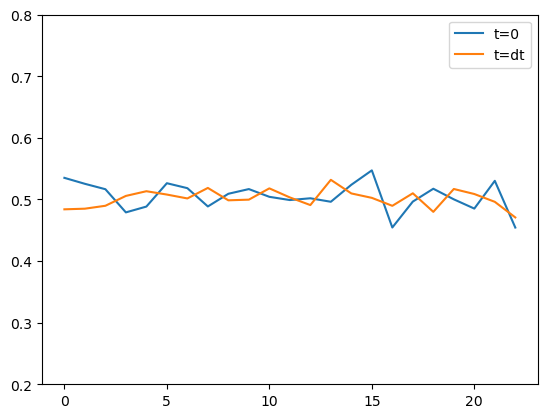

In [172]:
mean_over = 20
t0 = np.array([torch.mean(x).item() for x in loss_t_0])
t0_mean = t0[t0.shape[0]%mean_over:].reshape([-1,mean_over]).mean(axis=1)

t_dt = np.array([torch.mean(x).item() for x in loss_t_dt])
t_dt_mean = t_dt[t_dt.shape[0]%mean_over:].reshape([-1,mean_over]).mean(axis=1)

plt.plot(t0_mean, label='t=0')
plt.plot(t_dt_mean, label='t=dt')
plt.legend()
plt.ylim(0.2,.8)
plt.show()

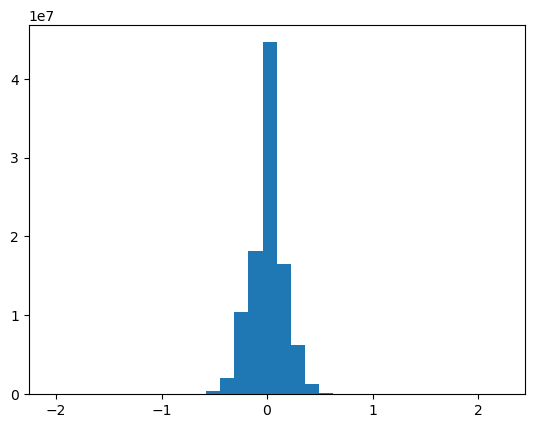

In [114]:
plt.hist(model.edge_params.detach().flatten(), bins=32)
plt.show()

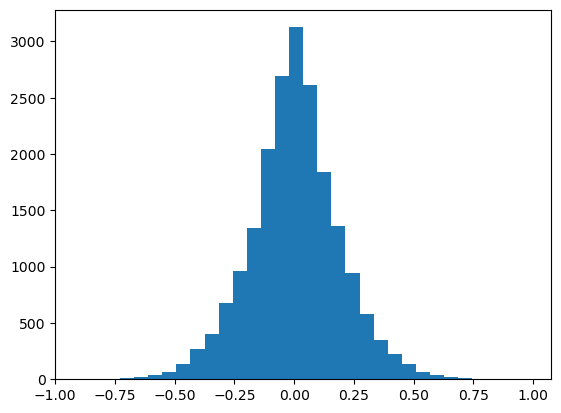

In [115]:
plt.hist(model.bias.detach().flatten(), bins=32)
plt.show()

In [97]:
sample = get_sample(values, xy)

model = gnn_model()

y_hat, _inp = model(
        inp_known=sample[1][0],
        inp_unknown=sample[1][1],
        t=sample[-1],
        edge_index_fully=sample[0][0],
        edge_index_partial=sample[0][0],
        edge_index_cls_mapping=sample[0][1]
    )
y = torch.cat([sample[2][:,-1:],sample[3][:,-1:]], dim=1)
loss = loss_fn(y,y_hat)

# check if this is correct place for zero grad
optimizer.zero_grad()
loss.backward()

In [98]:
model.edge_params.grad

tensor([[[[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]],

          [[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]],

          [[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]],

          ...,

          [[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           

(array([    0.,     0.,     0.,     0.,     0., 20000.,     0.,     0.,
            0.,     0.]),
 array([-0.5       , -0.40000001, -0.30000001, -0.2       , -0.1       ,
         0.        ,  0.1       ,  0.2       ,  0.30000001,  0.40000001,
         0.5       ]),
 <BarContainer object of 10 artists>)

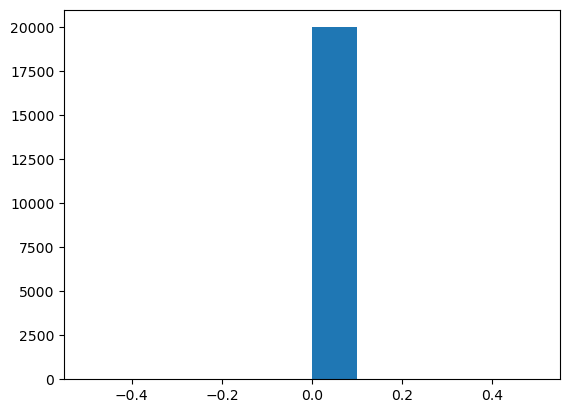

In [127]:
plt.hist(model.bias.grad.flatten())

In [129]:
model.edge_params.grad[model.edge_params.grad!=0]

tensor([-4.2929e-06, -5.4109e-07,  1.2454e-06,  ...,  1.0797e-07,
         8.1519e-08, -1.5079e-07])

(array([34.,  5.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 39.]),
 array([-0.07223335, -0.0605532 , -0.04887305, -0.0371929 , -0.02551275,
        -0.0138326 , -0.00215245,  0.0095277 ,  0.02120785,  0.032888  ,
         0.04456815]),
 <BarContainer object of 10 artists>)

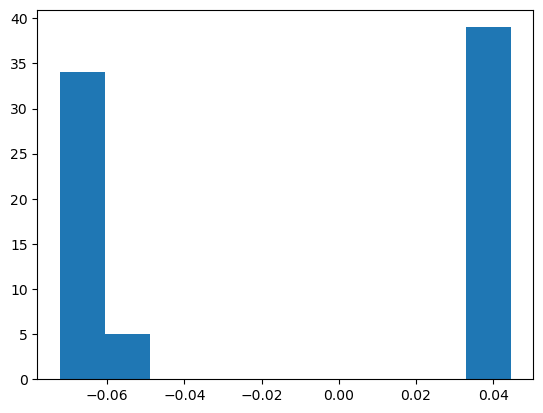

In [118]:
plt.hist(y_hat.flatten().detach())
#plt.hist(y.flatten().detach())

In [106]:
for _, i in zip(range(5), model.parameters()):
    pass
print(i.shape)

torch.Size([32, 32])


(array([105.,  92.,  96., 102.,  95., 118., 123., 107.,  85., 101.]),
 array([-1.76191807e-01, -1.40956670e-01, -1.05721541e-01, -7.04864040e-02,
        -3.52512710e-02, -1.61379576e-05,  3.52189951e-02,  7.04541281e-02,
         1.05689265e-01,  1.40924394e-01,  1.76159531e-01]),
 <BarContainer object of 10 artists>)

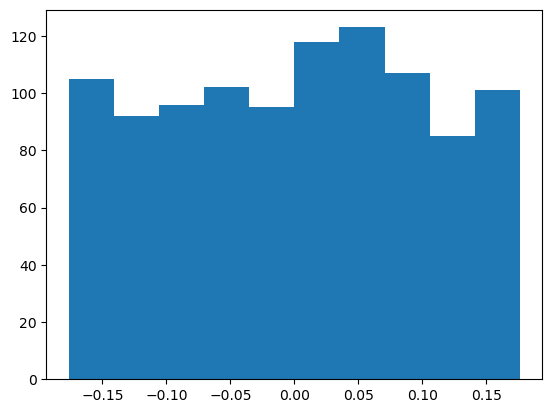

In [107]:
plt.hist(i.detach().flatten())

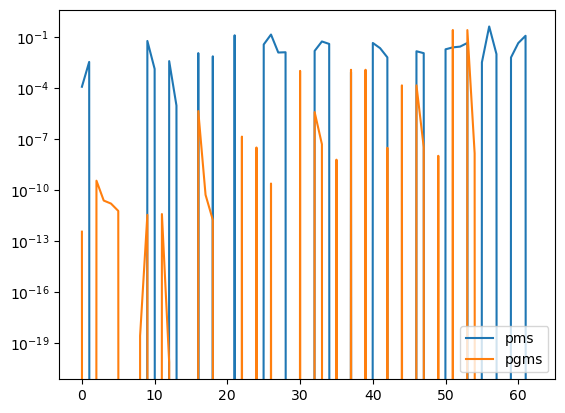

In [120]:
pms = []
pgms = []
for i, p in enumerate(model.parameters()):
    pms.append(torch.mean(p.detach()).item())
    if p.grad is not None:
        pgms.append(torch.mean(p.grad).item())
    else:
        pass
        #pgms.append(0)

plt.plot(pms, label='pms')
plt.plot(pgms, label='pgms')
plt.legend()
plt.yscale('log')
plt.show()


In [126]:
model.fe(sample[1][0])

tensor([[  -4.5076,  -59.3263,   56.1606,    8.0247,   27.6016,  -15.5533,
          -38.3568,  -28.9270],
        [  -6.4815,  -86.3893,   81.8120,   11.5603,   40.0500,  -22.5538,
          -55.6490,  -41.9900],
        [  -9.2700, -124.6222,  118.0507,   16.5551,   57.6363,  -32.4436,
          -80.0782,  -60.4444],
        [  -6.7871,  -90.5798,   85.7840,   12.1078,   41.9776,  -23.6378,
          -58.3266,  -44.0127],
        [  -8.6069, -115.5313,  109.4340,   15.3675,   53.4547,  -30.0920,
          -74.2696,  -56.0564],
        [  -7.4971, -100.3143,   95.0107,   13.3795,   46.4552,  -26.1558,
          -64.5465,  -48.7114],
        [  -6.3822,  -85.0285,   80.5222,   11.3825,   39.4241,  -22.2018,
          -54.7795,  -41.3331],
        [  -6.7540,  -90.1257,   85.3535,   12.0484,   41.7687,  -23.5203,
          -58.0364,  -43.7935],
        [  -5.1779,  -68.5161,   64.8710,    9.2253,   31.8287,  -17.9305,
          -44.2287,  -33.3628],
        [  -9.7537, -131.2542,  124.3

In [131]:
model.fe.parameters().__next__().grad[model.fe.parameters().__next__()!=0]

tensor([ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         2.6009e-13,  4.6817e-12,  1.0404e-11,  1.0653e-13,  2.3860e-11,
         4.2948e-10,  9.5440e-10,  9.7728e-12,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  1.9257e-10,  3.4662e-09,  7.7027e-09,  7.8873e-11,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0